# 遗传算法求解 Rastrigin 函数

仍考虑二维 Rastrigin 函数的约束优化问题

$$\min_{(x,y)\in D}f(x,y),\qquad D=[-5.12,5.12]^2,$$

$$f(x,y)=20+x^2+y^2-10\{\cos(2\pi x)+\cos(2\pi y)\}.$$

其全局最小值为 $f(0,0)=0$。上一实验已经展示了目标函数的多峰结构，这里直接使用 `DEAP` 实现遗传算法，并观察种群如何逐代集中到全局最优点附近。

## 编码与遗传机制

实验采用与正文一致的实数向量编码。每个个体为 $z=(x,y)\in D$，种群规模为 $N=120$，进化代数为 $G=200$，初始个体在 $D$上均匀生成。下面依次给出本实验对选择、交叉、变异和种群更新的具体实现。

**选择操作。**由于 Rastrigin 函数满足 $f(z)\geqslant0$，定义正适应度

$$F(z)=\frac{1}{1+f(z)}$$

目标函数值越小，适应度越大。设第 $t$ 代种群为 $\mathcal{D}_t=(z_1^{(t)},z_2^{(t)},\dots,z_N^{(t)})$，令

$$p_i^{(t)}=\frac{F(z_i^{(t)})}{\sum_{j=1}^{N}F(z_j^{(t)})},\qquad i=1,2,\dots,N$$

每次按照概率 $p_1^{(t)},p_2^{(t)},\dots,p_N^{(t)}$ 从当前种群中有放回地抽取一个亲本，重复抽取直到获得产生子代所需的全部亲本。

**交叉操作。**将依次抽取的两个亲本记为 $x,z\in D$。以概率 $p_c=0.9$ 生成 $\lambda\sim\operatorname{U}(0,1)$，并按照正文中的算术交叉生成

$$y_1=\lambda x+(1-\lambda)z,\qquad y_2=(1-\lambda)x+\lambda z.$$

若没有执行交叉，则直接复制两个亲本。由于 $D$ 是凸的盒约束，算术交叉所得子代仍属于 $D$。

**变异操作。**每个子代以概率 $p_m=0.2$ 发生变异。发生变异时，等概率选择一个坐标并加入 $\eta\sim\operatorname{N}(0,0.35^2)$；若新坐标越过边界，则将其截断到 $[-5.12,5.12]$，从而保证变异后的个体仍属于 $D$。

**种群更新。**每一代直接复制目标函数值最小的 $e=2$ 个个体，再用经过选择、交叉与变异产生的 $N-e$ 个子代补足下一代种群。

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
from deap import base, creator, tools

from figure_settings import configure_matplotlib

configure_matplotlib()

LOWER_BOUND, UPPER_BOUND = -5.12, 5.12
POPULATION_SIZE = 120
GENERATIONS = 200
CROSSOVER_PROBABILITY = 0.9
MUTATION_PROBABILITY = 0.2
MUTATION_SCALE = 0.35
ELITE_COUNT = 2


def rastrigin(individual):
    x, y = individual
    value = 20.0 + x**2 + y**2 - 10.0 * (
        math.cos(2.0 * math.pi * x) + math.cos(2.0 * math.pi * y)
    )
    return (value,)


def arithmetic_crossover(first, second):
    # 算术交叉：两个子代分别取 lambda 与 1-lambda 的对称组合。
    # 可行域 D 是凸的盒约束，因此交叉后的子代仍然属于 D。
    mixing_weight = random.random()
    first_parent = first[:]
    second_parent = second[:]
    for coordinate in range(2):
        first[coordinate] = (
            mixing_weight * first_parent[coordinate]
            + (1.0 - mixing_weight) * second_parent[coordinate]
        )
        second[coordinate] = (
            (1.0 - mixing_weight) * first_parent[coordinate]
            + mixing_weight * second_parent[coordinate]
        )
    return first, second


def gaussian_mutation(individual):
    # 实数变异：随机选择一个坐标并加入 N(0, 0.35^2) 扰动。
    # 扰动后使用投影（坐标截断）修复越过盒约束边界的个体。
    coordinate = random.randrange(2)
    individual[coordinate] += random.gauss(0.0, MUTATION_SCALE)
    individual[coordinate] = min(
        UPPER_BOUND, max(LOWER_BOUND, individual[coordinate])
    )
    return (individual,)


def fitness_proportionate_selection(individuals, count):
    # 选择操作：F=1/(1+f)，再按 p_i=F_i/sum(F_j) 有放回抽取亲本。
    weights = [1.0 / (1.0 + item.fitness.values[0]) for item in individuals]
    return random.choices(individuals, weights=weights, k=count)


# DEAP 的负权重只用于精英和历史最优个体的大小比较。
# 亲本选择使用上面明确定义的正适应度 F=1/(1+f)。
if not hasattr(creator, "RastriginFitnessMin"):
    creator.create("RastriginFitnessMin", base.Fitness, weights=(-1.0,))
if not hasattr(creator, "RastriginIndividual"):
    creator.create(
        "RastriginIndividual", list, fitness=creator.RastriginFitnessMin
    )

toolbox = base.Toolbox()
toolbox.register("coordinate", random.uniform, LOWER_BOUND, UPPER_BOUND)
toolbox.register(
    "individual", tools.initRepeat, creator.RastriginIndividual,
    toolbox.coordinate, n=2
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", rastrigin)
toolbox.register("select", fitness_proportionate_selection)
toolbox.register("mate", arithmetic_crossover)
toolbox.register("mutate", gaussian_mutation)

In [2]:
random.seed(2026)
population = toolbox.population(n=POPULATION_SIZE)

# 初始种群需要先计算适应度。后续只重新计算经过交叉或变异的个体。
for individual in population:
    individual.fitness.values = toolbox.evaluate(individual)

hall_of_fame = tools.HallOfFame(1)
hall_of_fame.update(population)
history = []


def record_generation(generation, current_population):
    objective_values = np.asarray(
        [individual.fitness.values[0] for individual in current_population]
    )
    coordinates = np.asarray(current_population, dtype=float)
    history.append(
        {
            "generation": generation,
            "best": objective_values.min(),
            "lower_quartile": np.quantile(objective_values, 0.25),
            "median": np.median(objective_values),
            "upper_quartile": np.quantile(objective_values, 0.75),
            "diversity": np.mean(np.std(coordinates, axis=0)),
        }
    )


record_generation(0, population)
for generation in range(1, GENERATIONS + 1):
    # 精英保留：先复制当前种群中目标函数值最小的 2 个个体。
    elites = [toolbox.clone(individual) for individual in tools.selBest(
        population, ELITE_COUNT
    )]

    # 按适应度比例有放回地选择亲本，再复制得到可以修改的子代。
    offspring = toolbox.select(population, POPULATION_SIZE - ELITE_COUNT)
    offspring = [toolbox.clone(individual) for individual in offspring]

    # 以概率 p_c 对相邻的两个子代执行算术交叉。
    for first, second in zip(offspring[::2], offspring[1::2]):
        if random.random() < CROSSOVER_PROBABILITY:
            toolbox.mate(first, second)
            del first.fitness.values
            del second.fitness.values

    # 以概率 p_m 对每个子代执行 Gaussian 变异与边界修复。
    for individual in offspring:
        if random.random() < MUTATION_PROBABILITY:
            toolbox.mutate(individual)
            del individual.fitness.values

    for individual in offspring:
        if not individual.fitness.valid:
            individual.fitness.values = toolbox.evaluate(individual)

    population = elites + offspring
    hall_of_fame.update(population)
    record_generation(generation, population)

best_individual = np.asarray(hall_of_fame[0], dtype=float)
best_objective = rastrigin(best_individual)[0]
print(f"Best individual: {best_individual}")
print(f"Best objective value: {best_objective:.8g}")
print("Theoretical minimizer: [0. 0.]")

Best individual: [-3.33386638e-05  2.66288495e-05]
Best objective value: 3.6118512e-07
Theoretical minimizer: [0. 0.]


## 优化过程

左图显示每一代种群中目标函数值的最优值、中位数与四分位区间。纵轴采用对数刻度，但刻度仍表示原始目标函数值，而不是其对数。右图以两个坐标标准差的平均值衡量种群多样性；选择与精英保留推动目标函数值下降，而交叉和变异在搜索过程中维持一定的个体差异。

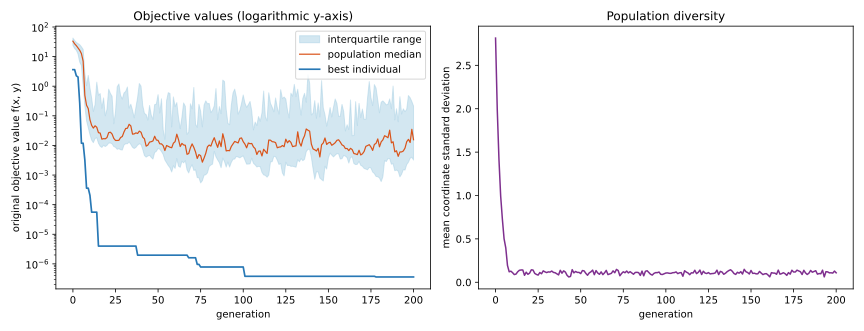

In [3]:
generation = np.asarray([record["generation"] for record in history])
best = np.asarray([record["best"] for record in history])
lower_quartile = np.asarray([record["lower_quartile"] for record in history])
median = np.asarray([record["median"] for record in history])
upper_quartile = np.asarray([record["upper_quartile"] for record in history])
diversity = np.asarray([record["diversity"] for record in history])
positive_floor = 1.0e-14

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].fill_between(
    generation, np.maximum(lower_quartile, positive_floor),
    np.maximum(upper_quartile, positive_floor), color="#9ECAE1",
    alpha=0.45, label="interquartile range"
)
axes[0].semilogy(
    generation, np.maximum(median, positive_floor), color="#D95319",
    linewidth=1.2, label="population median"
)
axes[0].semilogy(
    generation, np.maximum(best, positive_floor), color="#2878B5",
    linewidth=1.7, label="best individual"
)
axes[0].set(
    xlabel="generation", ylabel="original objective value f(x, y)",
    title="Objective values (logarithmic y-axis)"
)
axes[0].legend()

axes[1].plot(generation, diversity, color="#7E2F8E", linewidth=1.5)
axes[1].set(
    xlabel="generation", ylabel="mean coordinate standard deviation",
    title="Population diversity"
)
fig.tight_layout()
plt.show()

## 结果说明

初始种群分布在整个可行域中。适应度比例选择使目标函数值较小的个体具有更大的繁殖机会，算术交叉重组两个亲本的坐标信息，精英保留则避免已经找到的最优个体在随机更新中丢失；Gaussian 变异继续向种群引入新的坐标值，使算法仍有机会探索其他局部区域。最终最优个体位于原点附近，其目标函数值接近理论最小值 $0$。